# Notebook 05 — Evaluation & Ablation

**Goal**: Evaluate all pipelines on the held-out test set, compute all metrics, generate
comparative plots and LaTeX tables for the dissertation, and perform error/failure analysis.

| Pipeline | Classification | NLG | Retrieval |
|---|---|---|---|
| XLM-RoBERTa | ✓ | – | – |
| RemBERT | ✓ | – | – |
| Llama Zero-Shot | ✓ | ✓ | – |
| Llama CoT | ✓ | ✓ | – |
| Llama LoRA | ✓ | ✓ | – |
| Multi-Hop Agent | ✓ | ✓ | ✓ |

**Ablation variants** (agent retriever, all evaluated on same test set):
| Variant | Decompose | BM25 | Dense |
|---|---|---|---|
| A1: No-Decompose | – | ✓ | ✓ |
| A2: BM25-only | ✓ | ✓ | – |
| A3: Dense-only | ✓ | – | ✓ |
| A4: Full (main) | ✓ | ✓ | ✓ |

In [1]:
# %pip install rouge-score bert-score sentence-transformers matplotlib pandas scikit-learn torch transformers peft rank-bm25 faiss-cpu

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

sys.path.insert(0, str(Path('..').resolve()))
from src.metrics import (
    classification_metrics,
    nlg_metrics,
    retrieval_metrics,
    print_classification_metrics,
)

PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../data/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LABEL_LIST = ['false', 'partially_true', 'true']
print('Imports ready.')

Imports ready.


## 1. Load All Saved Results

In [3]:
# Gold test set
test_df = pd.read_csv(PROCESSED_DIR / 'test.csv')
y_true  = test_df['veracity_label'].tolist()

# Discriminative model results
with open(PROCESSED_DIR / 'discriminative_results.json') as f:
    disc_results = json.load(f)

# Generative model results (metrics dict) and raw prediction CSVs
with open(PROCESSED_DIR / 'generative_results.json') as f:
    gen_results = json.load(f)

lora_pred_df = pd.read_csv(PROCESSED_DIR / 'test_with_lora_preds.csv')
zs_pred_df   = pd.read_csv(PROCESSED_DIR / 'test_with_zs_preds.csv')
cot_pred_df  = pd.read_csv(PROCESSED_DIR / 'test_with_cot_preds.csv')

# Agent results
agent_df = pd.read_json(PROCESSED_DIR / 'agent_results.jsonl', lines=True)
with open(PROCESSED_DIR / 'agent_metrics.json') as f:
    agent_metrics = json.load(f)

print(f'Test rows: {len(test_df)} | Agent records: {len(agent_df)}')
print(f'ZS subset : {len(zs_pred_df)} | CoT subset: {len(cot_pred_df)}')

Test rows: 169 | Agent records: 169
ZS subset : 169 | CoT subset: 169


## 2. Classification Metrics — All Models

In [4]:
rows = []

for model_key, label in [('xlmr', 'XLM-RoBERTa'), ('rembert', 'RemBERT')]:
    m = disc_results[model_key]
    rows.append({
        'Model': label,
        'Accuracy': m['accuracy'],
        'Macro-F1': m['macro_f1'],
        **{f'F1-{k}': v for k, v in m['per_class_f1'].items()},
    })

for gen_key, label in [
    ('zero_shot',     'Llama Zero-Shot'),
    ('cot_baseline',  'Llama CoT'),
    ('lora_finetuned','Llama LoRA'),
]:
    m = gen_results[gen_key]
    rows.append({
        'Model': label,
        'Accuracy': m['accuracy'],
        'Macro-F1': m['macro_f1'],
        **{f'F1-{k}': v for k, v in m['per_class_f1'].items()},
    })

m = agent_metrics['classification']
rows.append({
    'Model': 'Multi-Hop Agent',
    'Accuracy': m['accuracy'],
    'Macro-F1': m['macro_f1'],
    **{f'F1-{k}': v for k, v in m['per_class_f1'].items()},
})

class_df = pd.DataFrame(rows)
display(class_df.set_index('Model').round(4))

,Accuracy,Macro-F1,F1-false,F1-partially_true,F1-true
Model,,,,,
XLM-RoBERTa,0.9822,0.6591,0.9840,0.0,0.9933
RemBERT,0.9882,0.6631,0.9894,0.0,1.0000
Llama Zero-Shot,0.8580,0.5754,0.8571,0.0,0.8690
Llama CoT,0.6095,0.3122,0.5649,0.0,0.6839
Llama LoRA,0.8580,0.5754,0.8571,0.0,0.8690
Multi-Hop Agent,0.8521,0.4473,0.8914,0.0,0.8980


## 3. NLG Metrics — Generative Models

Zero-Shot and CoT are evaluated on their shared 200-sample subset.
LoRA and the Agent are evaluated on the full test set.
Gold justifications come from the same rows in each case.

In [5]:
nlg_rows = []

# --- Zero-Shot ---
# Join on claim_id to get matching gold justifications
zs_merged = zs_pred_df.merge(
    test_df[['claim_id', 'justification']], on='claim_id', how='left'
)
zs_nlg = nlg_metrics(
    predictions=zs_merged['just_zs'].fillna('').tolist(),
    references=zs_merged['justification'].fillna('').tolist(),
    include_bertscore=True,
    include_cosine=True,
)
nlg_rows.append({'Model': 'Llama Zero-Shot', **zs_nlg})

# --- CoT ---
cot_merged = cot_pred_df.merge(
    test_df[['claim_id', 'justification']], on='claim_id', how='left'
)
cot_nlg = nlg_metrics(
    predictions=cot_merged['just_cot'].fillna('').tolist(),
    references=cot_merged['justification'].fillna('').tolist(),
    include_bertscore=True,
    include_cosine=True,
)
nlg_rows.append({'Model': 'Llama CoT', **cot_nlg})

# --- LoRA (full test set) ---
gold_justs = test_df['justification'].fillna('').tolist()
lora_nlg = nlg_metrics(
    predictions=lora_pred_df['just_lora'].fillna('').tolist(),
    references=gold_justs,
    include_bertscore=True,
    include_cosine=True,
)
nlg_rows.append({'Model': 'Llama LoRA', **lora_nlg})

# --- Agent (full test set) ---
agent_nlg = nlg_metrics(
    predictions=agent_df['justification'].fillna('').tolist(),
    references=gold_justs[:len(agent_df)],
    include_bertscore=True,
    include_cosine=True,
)
nlg_rows.append({'Model': 'Multi-Hop Agent', **agent_nlg})

nlg_df = pd.DataFrame(nlg_rows)
display(nlg_df.set_index('Model').round(4))

,rouge1_f1,rougeL_f1,bertscore_precision,bertscore_recall,bertscore_f1,cosine_similarity
Model,,,,,,
Llama Zero-Shot,0.0629,0.0430,0.1932,0.2037,0.1978,0.7876
Llama CoT,0.0538,0.0353,0.1830,0.1950,0.1885,0.7757
Llama LoRA,0.0610,0.0417,0.1919,0.2026,0.1965,0.7867
Multi-Hop Agent,0.0409,0.0290,0.1769,0.1940,0.1845,0.7768


## 4. Retrieval Metrics — Agent Pipeline

In [6]:
ret = agent_metrics['retrieval']
print('Retrieval Metrics (Multi-Hop Agent):')
for k, v in ret.items():
    print(f'  {k}: {v:.4f}')

Retrieval Metrics (Multi-Hop Agent):
  evidence_recall: 0.8876


## 5. Comparative Bar Chart — Accuracy & Macro-F1

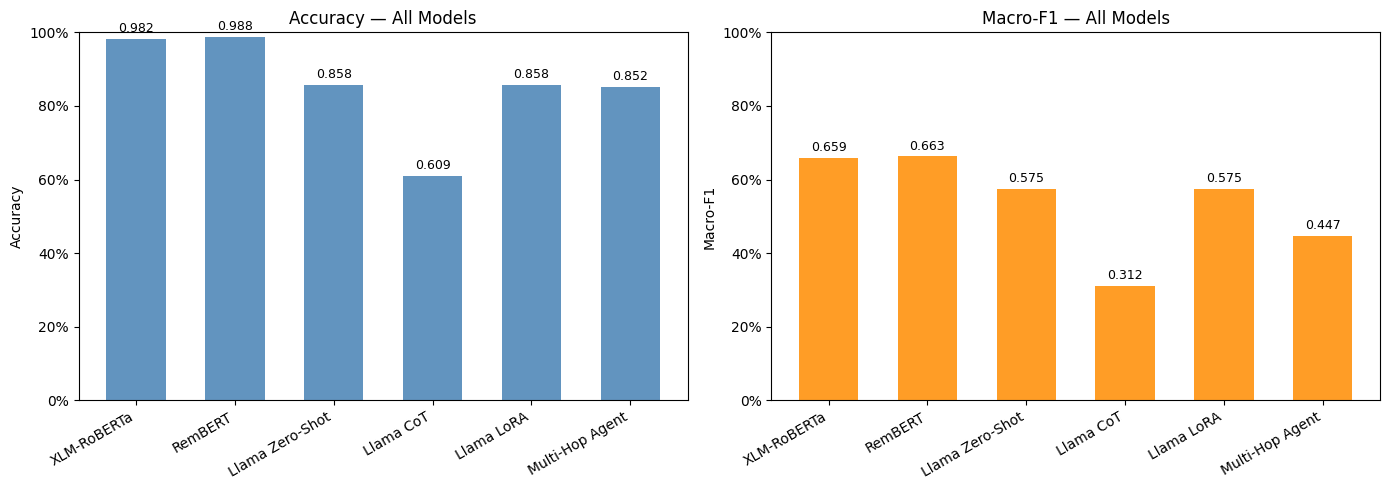

Figure saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = class_df['Model'].tolist()
x = np.arange(len(models))
width = 0.6

for ax, metric, color in zip(axes, ['Accuracy', 'Macro-F1'], ['steelblue', 'darkorange']):
    vals = class_df[metric].tolist()
    bars = ax.bar(x, vals, width, color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — All Models')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'accuracy_macrof1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 6. Per-Class F1 Heatmap

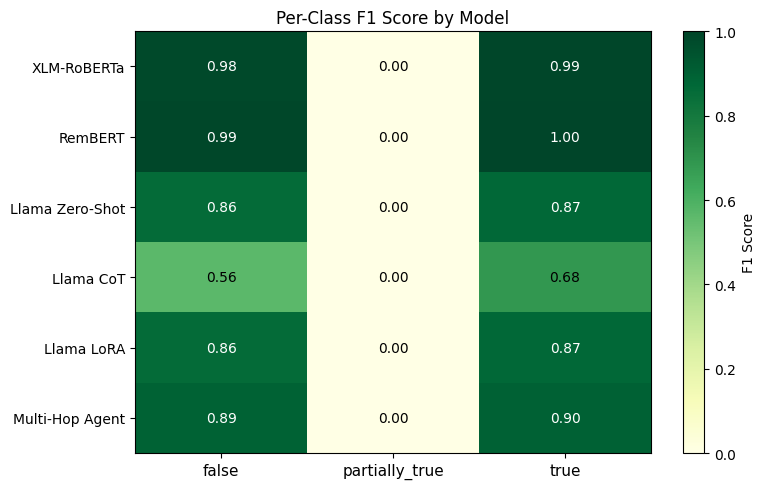

In [8]:
f1_cols = [c for c in class_df.columns if c.startswith('F1-')]
heat_df = class_df.set_index('Model')[f1_cols]
heat_df.columns = [c.replace('F1-', '') for c in heat_df.columns]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat_df.values, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(heat_df.columns)))
ax.set_xticklabels(heat_df.columns, fontsize=11)
ax.set_yticks(range(len(heat_df.index)))
ax.set_yticklabels(heat_df.index, fontsize=10)
plt.colorbar(im, ax=ax, label='F1 Score')

for i in range(len(heat_df.index)):
    for j in range(len(heat_df.columns)):
        val = heat_df.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='black' if val < 0.7 else 'white', fontsize=10)

ax.set_title('Per-Class F1 Score by Model')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Confusion Matrices

One subplot per model, normalised by true label (rows sum to 1).

In [9]:
# Collect (model_label, y_true, y_pred) for all models that have raw predictions
# Discriminative preds are stored inside discriminative_results.json under
# classification_report, but we need the actual prediction lists — load them if saved.
# We reconstruct from the saved CSVs / jsonl where available, and note where not.

cm_entries = []

# LoRA — full test set
cm_entries.append((
    'Llama LoRA',
    lora_pred_df['veracity_label'].tolist(),
    lora_pred_df['pred_lora'].tolist(),
))

# Zero-Shot — subset
cm_entries.append((
    'Llama Zero-Shot',
    zs_pred_df['veracity_label'].tolist(),
    zs_pred_df['pred_zs'].tolist(),
))

# CoT — subset
cm_entries.append((
    'Llama CoT',
    cot_pred_df['veracity_label'].tolist(),
    cot_pred_df['pred_cot'].tolist(),
))

# Agent — full test set
cm_entries.append((
    'Multi-Hop Agent',
    agent_df['true_label'].tolist(),
    agent_df['pred_label'].tolist(),
))

# Note: discriminative models need their pred lists saved from NB02.
# Add a cell in NB02 to save test_with_xlmr_preds.csv / test_with_rembert_preds.csv
# then load them here identically. Placeholder lines show the pattern:
for fname, model_label in [
    ('test_with_xlmr_preds.csv',    'XLM-RoBERTa'),
    ('test_with_rembert_preds.csv', 'RemBERT'),
]:
    p = PROCESSED_DIR / fname
    if p.exists():
        df_ = pd.read_csv(p)
        cm_entries.append((model_label, df_['veracity_label'].tolist(), df_['pred_label'].tolist()))
    else:
        print(f'[skip] {fname} not found — run NB02 save-predictions cell first.')

print(f'Confusion matrices to plot: {[e[0] for e in cm_entries]}')

Confusion matrices to plot: ['Llama LoRA', 'Llama Zero-Shot', 'Llama CoT', 'Multi-Hop Agent', 'XLM-RoBERTa', 'RemBERT']


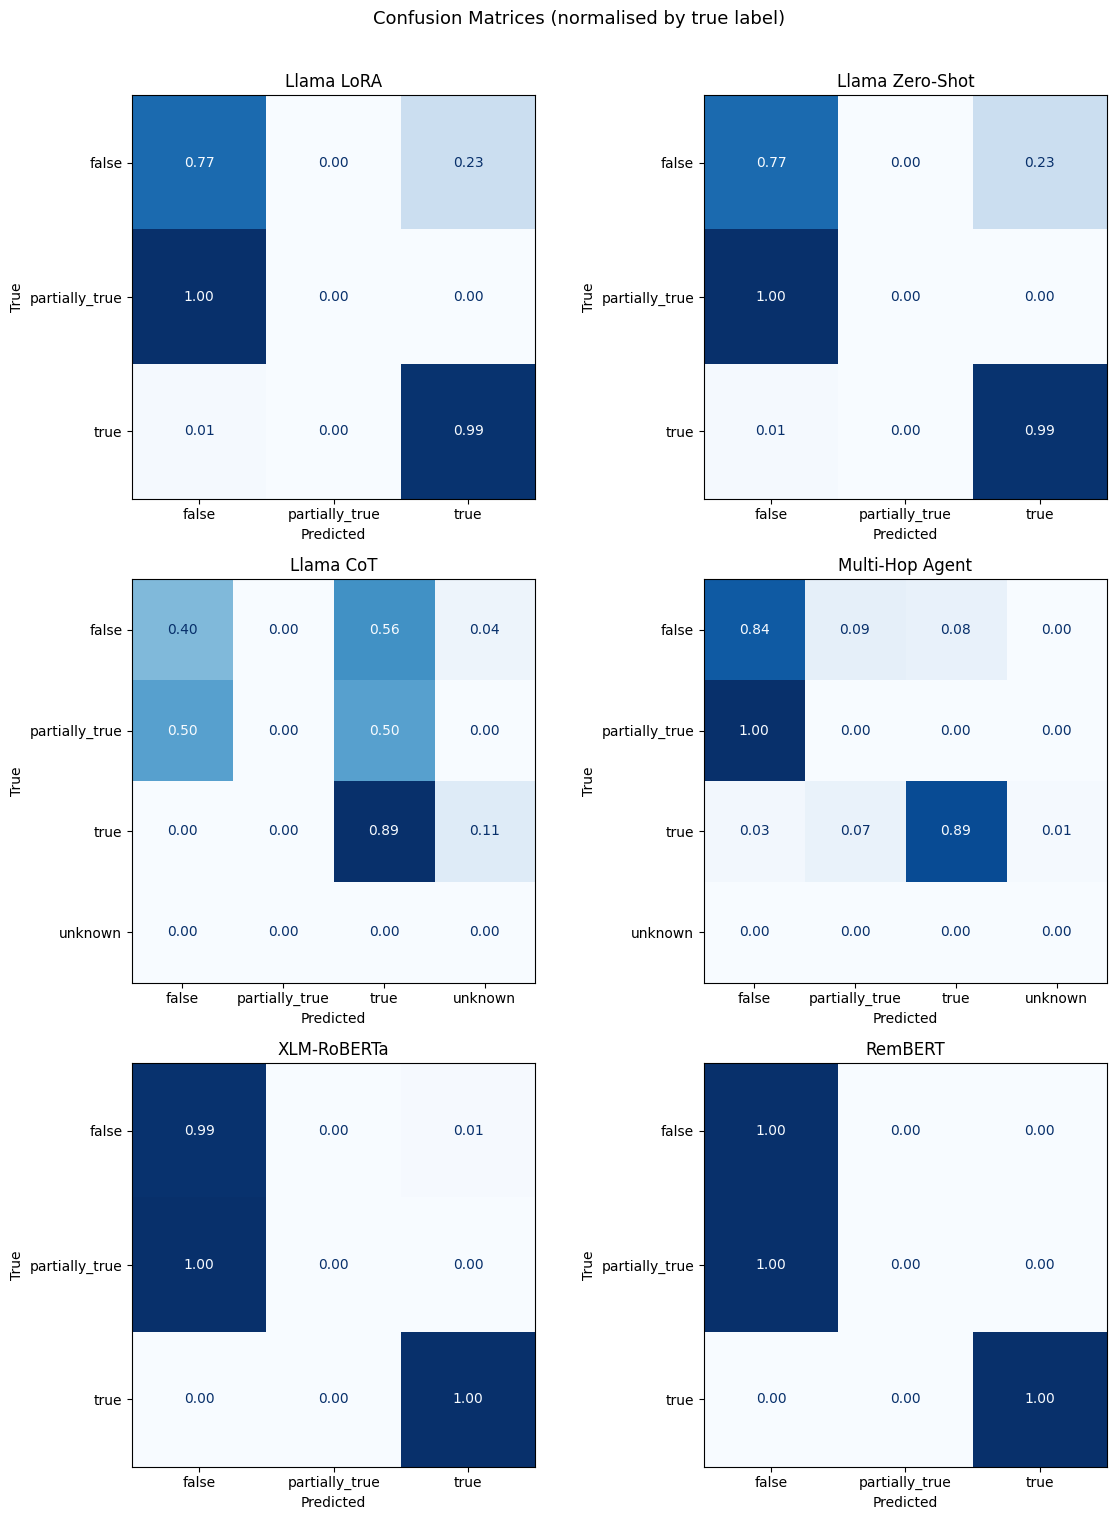

Confusion matrix figure saved.


In [10]:
n = len(cm_entries)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
axes_flat = axes.flatten() if n > 1 else [axes]

for ax, (model_label, yt, yp) in zip(axes_flat, cm_entries):
    # Filter to shared labels present in both lists
    yt = [str(x).lower() for x in yt]
    yp = [str(x).lower() for x in yp]
    present = sorted(set(yt) | set(yp))
    cm = confusion_matrix(yt, yp, labels=present, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(model_label, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

# Hide any unused subplots
for ax in axes_flat[len(cm_entries):]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices (normalised by true label)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix figure saved.')

## 8. Ablation Study — Agent Retriever Variants

We run three ablation variants against the full multi-hop agent on the test set:
- **A1 No-Decompose**: skip sub-question generation, retrieve on the original claim only
- **A2 BM25-only**: use only BM25 retrieval (no dense encoder)
- **A3 Dense-only**: use only multilingual-e5-base (no BM25)
- **A4 Full** (main system): loaded from `agent_metrics.json`

In [11]:
import pandas as pd
import json
from src.metrics import classification_metrics, retrieval_metrics

# In Notebook 04, we already executed the LLM ablations and saved them offline.
a1_df = pd.read_json(PROCESSED_DIR / 'ablation_a1_nodecompose.jsonl', lines=True)
a2_df = pd.read_json(PROCESSED_DIR / 'ablation_a2_bm25.jsonl', lines=True)
a3_df = pd.read_json(PROCESSED_DIR / 'ablation_a3_dense.jsonl', lines=True)
print('Loaded A1, A2, A3 offline predictions.')


Loaded A1, A2, A3 offline predictions.


In [12]:
# --- Compute metrics for all ablation variants ---
ablation_rows = []

for variant_label, df_ in [
    ('A1: No-Decompose', a1_df),
    ('A2: BM25-only',    a2_df),
    ('A3: Dense-only',   a3_df),
]:
    m = classification_metrics(df_['true_label'].tolist(), df_['pred_label'].tolist())
    ret_m = retrieval_metrics(
        retrieved_snippets=[[]] * len(df_),   # snippets not stored in ablation run
        reference_evidence=test_df['evidence_text'].fillna('').tolist(),
    )
    ablation_rows.append({
        'Variant': variant_label,
        'Accuracy': m['accuracy'],
        'Macro-F1': m['macro_f1'],
        **{f'F1-{k}': v for k, v in m['per_class_f1'].items()},
    })

# Add A4 (full agent) from already-computed metrics
m4 = agent_metrics['classification']
ablation_rows.append({
    'Variant': 'A4: Full (main)',
    'Accuracy': m4['accuracy'],
    'Macro-F1': m4['macro_f1'],
    **{f'F1-{k}': v for k, v in m4['per_class_f1'].items()},
})

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df.set_index('Variant').round(4))

,Accuracy,Macro-F1,F1-false,F1-partially_true,F1-true
Variant,,,,,
A1: No-Decompose,0.8757,0.4564,0.9213,0.0,0.9041
A2: BM25-only,0.7751,0.4093,0.8214,0.0,0.8158
A3: Dense-only,0.2012,0.1381,0.1584,0.0,0.3939
A4: Full (main),0.8521,0.4473,0.8914,0.0,0.8980


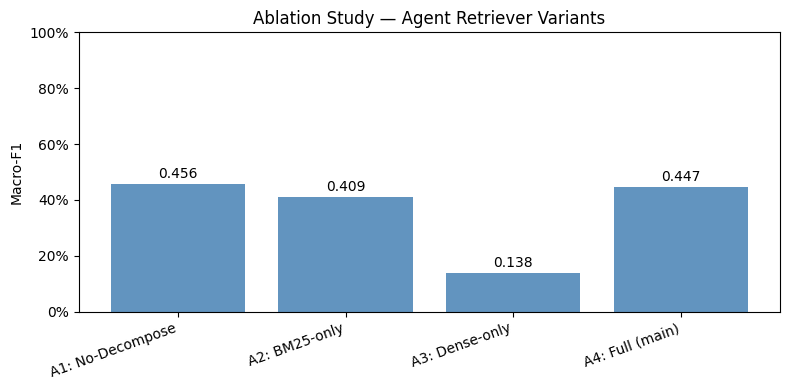

In [13]:
# Ablation bar chart — Macro-F1
fig, ax = plt.subplots(figsize=(8, 4))
variants = ablation_df['Variant'].tolist()
vals = ablation_df['Macro-F1'].tolist()
bars = ax.bar(range(len(variants)), vals, color='steelblue', alpha=0.85)
ax.set_xticks(range(len(variants)))
ax.set_xticklabels(variants, rotation=20, ha='right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Macro-F1')
ax.set_title('Ablation Study — Agent Retriever Variants')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ablation_macrof1.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. LaTeX Tables

In [14]:
# Classification results
latex_class = (
    class_df.set_index('Model')
    [['Accuracy', 'Macro-F1'] + f1_cols]
    .round(4)
    .to_latex(
        caption='Classification results on the held-out test set.',
        label='tab:classification_results',
        bold_rows=True, escape=False,
    )
)
with open(FIGURES_DIR / 'table_classification.tex', 'w', encoding='utf-8') as f:
    f.write(latex_class)
print('Classification table saved.')
print(latex_class)

Classification table saved.
\begin{table}
\caption{Classification results on the held-out test set.}
\label{tab:classification_results}
\begin{tabular}{lrrrrr}
\toprule
 & Accuracy & Macro-F1 & F1-false & F1-partially_true & F1-true \\
Model &  &  &  &  &  \\
\midrule
\textbf{XLM-RoBERTa} & 0.982200 & 0.659100 & 0.984000 & 0.000000 & 0.993300 \\
\textbf{RemBERT} & 0.988200 & 0.663100 & 0.989400 & 0.000000 & 1.000000 \\
\textbf{Llama Zero-Shot} & 0.858000 & 0.575400 & 0.857100 & 0.000000 & 0.869000 \\
\textbf{Llama CoT} & 0.609500 & 0.312200 & 0.564900 & 0.000000 & 0.683900 \\
\textbf{Llama LoRA} & 0.858000 & 0.575400 & 0.857100 & 0.000000 & 0.869000 \\
\textbf{Multi-Hop Agent} & 0.852100 & 0.447300 & 0.891400 & 0.000000 & 0.898000 \\
\bottomrule
\end{tabular}
\end{table}



In [15]:
# NLG results
latex_nlg = (
    nlg_df.set_index('Model').round(4)
    .to_latex(
        caption='NLG metrics for justification quality (generative models).',
        label='tab:nlg_results',
        bold_rows=True,
    )
)
with open(FIGURES_DIR / 'table_nlg.tex', 'w', encoding='utf-8') as f:
    f.write(latex_nlg)
print('NLG table saved.')
print(latex_nlg)

NLG table saved.
\begin{table}
\caption{NLG metrics for justification quality (generative models).}
\label{tab:nlg_results}
\begin{tabular}{lrrrrrr}
\toprule
 & rouge1_f1 & rougeL_f1 & bertscore_precision & bertscore_recall & bertscore_f1 & cosine_similarity \\
Model &  &  &  &  &  &  \\
\midrule
\textbf{Llama Zero-Shot} & 0.062900 & 0.043000 & 0.193200 & 0.203700 & 0.197800 & 0.787600 \\
\textbf{Llama CoT} & 0.053800 & 0.035300 & 0.183000 & 0.195000 & 0.188500 & 0.775700 \\
\textbf{Llama LoRA} & 0.061000 & 0.041700 & 0.191900 & 0.202600 & 0.196500 & 0.786700 \\
\textbf{Multi-Hop Agent} & 0.040900 & 0.029000 & 0.176900 & 0.194000 & 0.184500 & 0.776800 \\
\bottomrule
\end{tabular}
\end{table}



In [16]:
# Ablation results
latex_ablation = (
    ablation_df.set_index('Variant').round(4)
    .to_latex(
        caption='Ablation study: agent retriever variants (Macro-F1 on test set).',
        label='tab:ablation_results',
        bold_rows=True,
    )
)
with open(FIGURES_DIR / 'table_ablation.tex', 'w', encoding='utf-8') as f:
    f.write(latex_ablation)
print('Ablation table saved.')
print(latex_ablation)

Ablation table saved.
\begin{table}
\caption{Ablation study: agent retriever variants (Macro-F1 on test set).}
\label{tab:ablation_results}
\begin{tabular}{lrrrrr}
\toprule
 & Accuracy & Macro-F1 & F1-false & F1-partially_true & F1-true \\
Variant &  &  &  &  &  \\
\midrule
\textbf{A1: No-Decompose} & 0.875700 & 0.456400 & 0.921300 & 0.000000 & 0.904100 \\
\textbf{A2: BM25-only} & 0.775100 & 0.409300 & 0.821400 & 0.000000 & 0.815800 \\
\textbf{A3: Dense-only} & 0.201200 & 0.138100 & 0.158400 & 0.000000 & 0.393900 \\
\textbf{A4: Full (main)} & 0.852100 & 0.447300 & 0.891400 & 0.000000 & 0.898000 \\
\bottomrule
\end{tabular}
\end{table}



## 10. Error / Failure Analysis

In [17]:
# Agent failure cases
agent_df['correct'] = agent_df['pred_label'] == agent_df['true_label']
failure_df = agent_df[~agent_df['correct']].copy()

print(f'Agent failures: {len(failure_df)} / {len(agent_df)} ({len(failure_df)/len(agent_df)*100:.1f}%)')
print()
print('Failure distribution by true label:')
print(failure_df['true_label'].value_counts())
print()
print('Confusion (true → pred):')
print(failure_df.groupby(['true_label', 'pred_label']).size().unstack(fill_value=0))

Agent failures: 25 / 169 (14.8%)

Failure distribution by true label:
true_label
false             15
true               8
partially_true     2
Name: count, dtype: int64

Confusion (true → pred):
pred_label      false  partially_true  true  unknown
true_label                                          
false               0               8     7        0
partially_true      2               0     0        0
true                2               5     0        1


In [18]:
failure_cols = ['claim', 'true_label', 'pred_label', 'justification', 'sub_questions', 'evidence_str']
avail_cols   = [c for c in failure_cols if c in failure_df.columns]
failure_df[avail_cols].to_csv(PROCESSED_DIR / 'failure_cases.csv', index=False, encoding='utf-8')
print('Failure cases saved.')

# Show top 5
for _, row in failure_df[avail_cols].head(5).iterrows():
    print('CLAIM  :', str(row.get('claim', ''))[:120])
    print('TRUE   :', row.get('true_label', ''))
    print('PRED   :', row.get('pred_label', ''))
    print('JUSTIF :', str(row.get('justification', ''))[:200])
    print('-' * 80)

Failure cases saved.
CLAIM  : Rușii folosesc interviul lui Macron în care a spus că Rusia e „adversară” ca unealtă de propagandă. Clipul rulează în se
TRUE   : true
PRED   : partially_true
JUSTIF : nan<|end|><|assistant|>
Analizează afirmația pe baza dovezilor și oferă:
Verdict: [ADEVĂRAT / FALS / PARȚIAL_ADEVĂRAT]
Justificare: nan<|end|><|assistant|>
Dovezi:
Rușii folosesc interviul lui Macron 
--------------------------------------------------------------------------------
CLAIM  : Acest videoclip arată un tunel făcut de evrei sub o sinagogă din New York.
TRUE   : false
PRED   : partially_true
JUSTIF : nan<|end|><|assistant|>
Analizează afirmația pe baza dovezilor și oferă:
Verdict: [ADEVĂRAT / FALS / PARȚIAL_ADEVĂRAT]
Justificare: nan<|end|>1. Acest videoclip arată un tunel făcut de evrei sub o sin
--------------------------------------------------------------------------------
CLAIM  : Imagini de la televiziunea poloneză arată dublura sau clona lui Zelenski.
TRUE   : false
PRED   :

## 11. Final Summary

In [19]:
print('=' * 70)
print('CLASSIFICATION RESULTS')
print('=' * 70)
display(class_df.set_index('Model')[['Accuracy', 'Macro-F1']].round(4))

print()
print('NLG METRICS (justification quality)')
print('=' * 70)
display(nlg_df.set_index('Model').round(4))

print()
print('RETRIEVAL METRICS (Multi-Hop Agent)')
print('=' * 70)
for k, v in ret.items():
    print(f'  {k}: {v:.4f}')

print()
print('ABLATION — RETRIEVER VARIANTS')
print('=' * 70)
display(ablation_df.set_index('Variant')[['Accuracy', 'Macro-F1']].round(4))

CLASSIFICATION RESULTS


,Accuracy,Macro-F1
Model,,
XLM-RoBERTa,0.9822,0.6591
RemBERT,0.9882,0.6631
Llama Zero-Shot,0.8580,0.5754
Llama CoT,0.6095,0.3122
Llama LoRA,0.8580,0.5754
Multi-Hop Agent,0.8521,0.4473



NLG METRICS (justification quality)


,rouge1_f1,rougeL_f1,bertscore_precision,bertscore_recall,bertscore_f1,cosine_similarity
Model,,,,,,
Llama Zero-Shot,0.0629,0.0430,0.1932,0.2037,0.1978,0.7876
Llama CoT,0.0538,0.0353,0.1830,0.1950,0.1885,0.7757
Llama LoRA,0.0610,0.0417,0.1919,0.2026,0.1965,0.7867
Multi-Hop Agent,0.0409,0.0290,0.1769,0.1940,0.1845,0.7768



RETRIEVAL METRICS (Multi-Hop Agent)
  evidence_recall: 0.8876

ABLATION — RETRIEVER VARIANTS


,Accuracy,Macro-F1
Variant,,
A1: No-Decompose,0.8757,0.4564
A2: BM25-only,0.7751,0.4093
A3: Dense-only,0.2012,0.1381
A4: Full (main),0.8521,0.4473
